In [64]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [65]:
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.size"] = 16

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV, 
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder

from scipy.stats import loguniform

In [66]:
import hashlib


def my_sha1(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

## Option 1 - Default of Credit Card Clients Dataset

This is an imbalanced binary classification problem where the accuracy metric is probably misleading. We'd rather use F1-score, AUC-ROC or precision-recall as evaluation criteria. The most predictive features are likely the PAY repayment status columns, since clients who are already 2+ months late are strongly predictive of future defaults.

### There are 25 variables:

- **ID**: ID of each client  
- **LIMIT_BAL**: Amount of given credit in NT dollars (includes individual and family/supplementary credit)  
- **SEX**: Gender (1=male, 2=female)  
- **EDUCATION**: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)  
- **MARRIAGE**: Marital status (1=married, 2=single, 3=others)  
- **AGE**: Age in years  
- **PAY_0**: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)  
- **PAY_2**: Repayment status in August, 2005 (scale same as above)  
- **PAY_3**: Repayment status in July, 2005 (scale same as above)  
- **PAY_4**: Repayment status in June, 2005 (scale same as above)  
- **PAY_5**: Repayment status in May, 2005 (scale same as above)  
- **PAY_6**: Repayment status in April, 2005 (scale same as above)  
- **BILL_AMT1**: Amount of bill statement in September, 2005 (NT dollar)  
- **BILL_AMT2**: Amount of bill statement in August, 2005 (NT dollar)  
- **BILL_AMT3**: Amount of bill statement in July, 2005 (NT dollar)  
- **BILL_AMT4**: Amount of bill statement in June, 2005 (NT dollar)  
- **BILL_AMT5**: Amount of bill statement in May, 2005 (NT dollar)  
- **BILL_AMT6**: Amount of bill statement in April, 2005 (NT dollar)  
- **PAY_AMT1**: Amount of previous payment in September, 2005 (NT dollar)  
- **PAY_AMT2**: Amount of previous payment in August, 2005 (NT dollar)  
- **PAY_AMT3**: Amount of previous payment in July, 2005 (NT dollar)  
- **PAY_AMT4**: Amount of previous payment in June, 2005 (NT dollar)  
- **PAY_AMT5**: Amount of previous payment in May, 2005 (NT dollar)  
- **PAY_AMT6**: Amount of previous payment in April, 2005 (NT dollar)  
- **default.payment.next.month**: Default payment (1=yes, 0=no)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [67]:
# Load data
data = pd.read_csv("data/UCI_Credit_Card.csv")

# Split data 70/30
X = data.drop(columns=["default.payment.next.month"])
y = data["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

### Summary of the initial EDA

The dataset shows a 22.3% default rate with moderate class imbalance. Payment history (PAY_0–PAY_6) is the strongest predictor. Delaying payments by 2+ months increases default risk to 70%+, while paying duly keeps risk at ~13%. Credit limit inversely correlates with default risk, dropping from 35% for low-limit customers to 11% for high-limit ones. Demographics show weaker but notable patterns: males, high school graduates, and older customers (60+) default more frequently. Surprisingly, bill and payment amounts correlate weakly with default, suggesting timeliness matters more than dollar amounts.

### Select evaluation metrics

For this credit default prediction problem with 22.3% class imbalance, I recommend:

**1. ROC-AUC**: It evaluates the model's ability to distinguish between classes across all thresholds and is robust to class imbalance. Essential for credit scoring where you need good ranking of risk scores.

**2. Recall (Sensitivity)**: We want to catch as many actual defaulters as possible. Missing a defaulter (false negative) is typically more costly than incorrectly flagging a good customer.

**3. F1-Score**: Balances precision and recall, useful when you need a single metric that accounts for both false positives (wrongly rejecting good customers) and false negatives (approving risky customers).

In [68]:
# Combine features and target for convenience
train_df = X_train.copy()
train_df["default.payment.next.month"] = y_train

# Cleaning some features
train_df["EDUCATION"] = train_df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})  # EDUCATION: 1,2,3 as-is; 0,4,5,6 → 4 ("other/unknown")
train_df["MARRIAGE"] = train_df["MARRIAGE"].replace({0: 3})                # MARRIAGE: 1,2 as-is; 0,3 → 3 ("other/unknown")

In [69]:
# Basic structure
print("Training feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)
print("\nFirst 5 rows of training data:")
display(train_df.head())

Training feature shape: (21000, 24)
Test feature shape: (9000, 24)

First 5 rows of training data:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
16395,16396,320000.0,2,1,2,36,0,0,0,0,...,19370.0,10155.0,3788.0,5000.0,5018.0,1000.0,3000.0,0.0,7013.0,0
21448,21449,440000.0,2,1,2,30,-1,-1,-1,0,...,171244.0,150897.0,117870.0,612.0,87426.0,130007.0,3018.0,15000.0,51663.0,0
20034,20035,160000.0,2,3,1,44,-2,-2,-2,-2,...,-18.0,-18.0,-18.0,0.0,0.0,0.0,0.0,0.0,0.0,0
25755,25756,120000.0,2,2,1,30,0,0,0,0,...,103058.0,71095.0,47379.0,3706.0,5502.0,4204.0,3017.0,2005.0,1702.0,0
1438,1439,50000.0,1,2,2,54,1,2,0,0,...,27585.0,27910.0,27380.0,0.0,1400.0,1200.0,1500.0,1000.0,1500.0,0


In [70]:
# Summary statistics

target_col = "default.payment.next.month"

# Numeric summary statistics
print("\nSummary statistics for numeric features:")
display(train_df.describe().T)

# Default rate overall
print("\nOverall default rate in the training set:")
default_rate = y_train.mean()
print(f"Default rate: {default_rate:.3f}")

# Default rate by SEX
print("\nDefault rate by SEX (1 = male, 2 = female):")
default_by_sex = (
    train_df
    .groupby("SEX")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_sex)

# Default rate by EDUCATION
print(
    "\nDefault rate by EDUCATION "
    "(1 = graduate school, 2 = university, 3 = high school, "
    "4 = others):"
)
default_by_edu = (
    train_df
    .groupby("EDUCATION")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_edu)

# Default rate by MARRIAGE
print(
    "\nDefault rate by MARRIAGE "
    "(1 = married, 2 = single, 3 = others):"
)
default_by_marriage = (
    train_df
    .groupby("MARRIAGE")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_marriage)

# Default rate by AGE bands
print(
    "\nDefault rate by AGE band "
    "(20–29, 30–39, 40–49, 50–59, 60+):"
)
age_bins = [20, 30, 40, 50, 60, 80]
age_labels = ["20–29", "30–39", "40–49", "50–59", "60+"]

train_df["AGE_band"] = pd.cut(
    train_df["AGE"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

default_by_age_band = (
    train_df
    .groupby("AGE_band", observed=False)[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_age_band)

# Default rate by credit limit LIMIT_BAL bands
print("\nDefault rate by LIMIT_BAL band (NT$):")
limit_bins = [0, 50000, 100000, 200000, 500000, 1000000]
limit_labels = ["≤50k", "50k–100k", "100k–200k", "200k–500k", "500k+"]

train_df["LIMIT_BAL_band"] = pd.cut(
    train_df["LIMIT_BAL"],
    bins=limit_bins,
    labels=limit_labels,
    right=False
)

default_by_limit = (
    train_df
    .groupby("LIMIT_BAL_band", observed=False)[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_limit)

# Default rate by PAY_0 (repayment status Sept 2005: -1=pay duly, 1+=months delayed)
print("\nDefault rate by PAY_0 (repayment status in September 2005):")
default_by_pay0 = (
    train_df
    .groupby("PAY_0")[target_col]
    .mean()
    .rename("default_rate")
)
display(default_by_pay0)


Summary statistics for numeric features:


,count,mean,std,min,25%,50%,75%,max
ID,21000.0,14962.348238,8650.734050,1.0,7498.75,14960.5,22458.25,30000.0
LIMIT_BAL,21000.0,167880.651429,130202.682167,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,21000.0,1.600762,0.489753,1.0,1.00,2.0,2.00,2.0
EDUCATION,21000.0,1.840714,0.745167,1.0,1.00,2.0,2.00,4.0
MARRIAGE,21000.0,1.558857,0.521149,1.0,1.00,2.0,2.00,3.0
AGE,21000.0,35.500810,9.212644,21.0,28.00,34.0,41.00,79.0
PAY_0,21000.0,-0.015429,1.120465,-2.0,-1.00,0.0,0.00,8.0
PAY_2,21000.0,-0.137095,1.194506,-2.0,-1.00,0.0,0.00,8.0
PAY_3,21000.0,-0.171619,1.196123,-2.0,-1.00,0.0,0.00,8.0
PAY_4,21000.0,-0.225238,1.168556,-2.0,-1.00,0.0,0.00,8.0



Overall default rate in the training set:
Default rate: 0.223

Default rate by SEX (1 = male, 2 = female):


SEX
1    0.246899
2    0.207514
Name: default_rate, dtype: float64


Default rate by EDUCATION (1 = graduate school, 2 = university, 3 = high school, 4 = others):


...

AGE_band
20–29    0.230655
30–39    0.207182
40–49    0.226675
50–59    0.249229
60+      0.300000
Name: default_rate, dtype: float64


Default rate by LIMIT_BAL band (NT$):


LIMIT_BAL_band
≤50k         0.354464
50k–100k     0.262978
100k–200k    0.210023
200k–500k    0.160073
500k+        0.112121
Name: default_rate, dtype: float64


Default rate by PAY_0 (repayment status in September 2005):


PAY_0
-2    0.136243
-1    0.168687
 0    0.128088
 1    0.349280
 2    0.698815
 3    0.755365
 4    0.632653
 5    0.500000
 6    0.500000
 7    0.777778
 8    0.454545
Name: default_rate, dtype: float64

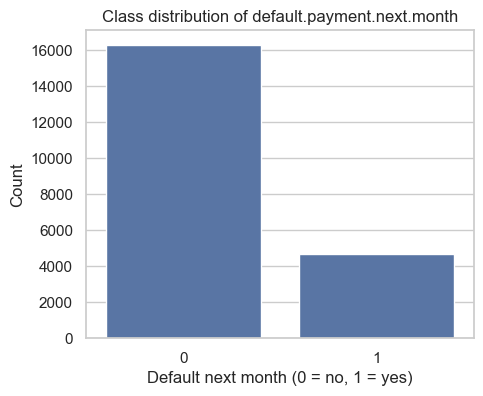

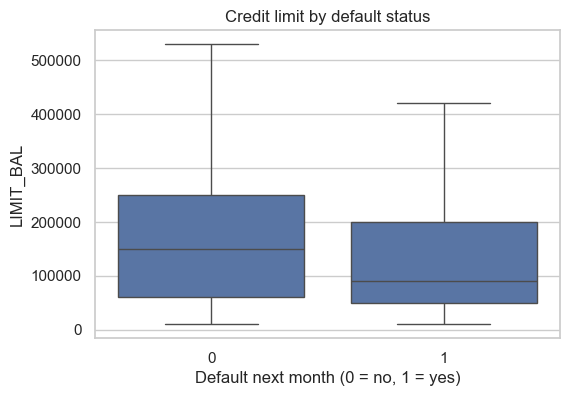

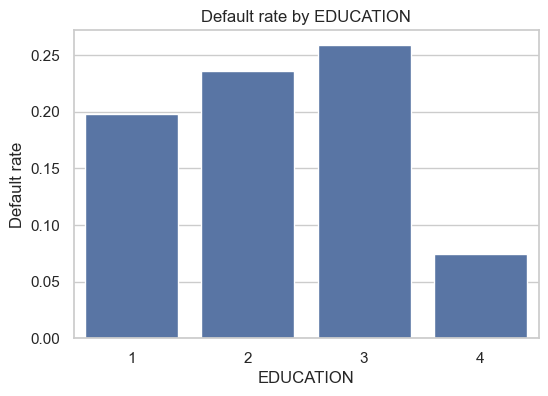

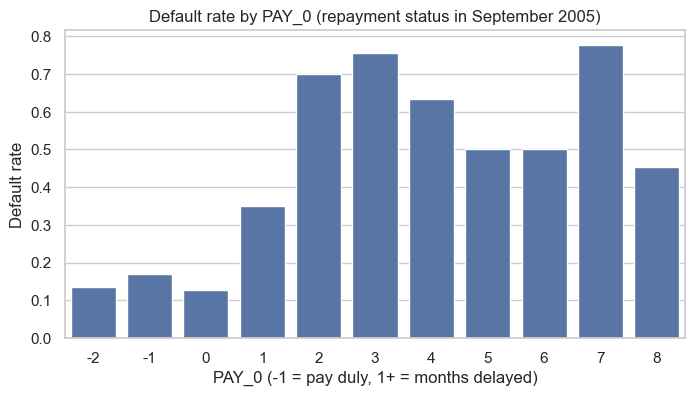

In [71]:
# Visualizations

sns.set_theme(style="whitegrid")

# Class balance of the target
plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=train_df)
plt.title("Class distribution of default.payment.next.month")
plt.xlabel("Default next month (0 = no, 1 = yes)")
plt.ylabel("Count")
plt.show()

# Distribution of credit limit by default status
plt.figure(figsize=(6, 4))
sns.boxplot(
    x=target_col,
    y="LIMIT_BAL",
    data=train_df,
    showfliers=False
)
plt.title("Credit limit by default status")
plt.xlabel("Default next month (0 = no, 1 = yes)")
plt.ylabel("LIMIT_BAL")
plt.show()

# Default rate by EDUCATION
plt.figure(figsize=(6, 4))
edu_default = (
    train_df
    .groupby("EDUCATION")[target_col]
    .mean()
    .reset_index(name="default_rate")
)
sns.barplot(x="EDUCATION", y="default_rate", data=edu_default)
plt.title("Default rate by EDUCATION")
plt.ylabel("Default rate")
plt.show()

# Default rate by PAY_0 (repayment status Sept 2005: -1=pay duly, 1+=months delayed)
plt.figure(figsize=(8, 4))
pay0_default = (
    train_df
    .groupby("PAY_0")[target_col]
    .mean()
    .reset_index(name="default_rate")
)
sns.barplot(x="PAY_0", y="default_rate", data=pay0_default)
plt.title("Default rate by PAY_0 (repayment status in September 2005)")
plt.xlabel("PAY_0 (-1 = pay duly, 1+ = months delayed)")
plt.ylabel("Default rate")
plt.show()


Correlation of numeric features with the target:


default.payment.next.month    1.000000
PAY_0                         0.325102
PAY_2                         0.265160
PAY_3                         0.240503
PAY_4                         0.219692
PAY_5                         0.208726
PAY_6                         0.194787
EDUCATION                     0.032647
AGE                           0.010715
BILL_AMT6                    -0.004944
BILL_AMT5                    -0.007868
BILL_AMT4                    -0.012313
BILL_AMT3                    -0.014718
BILL_AMT2                    -0.015301
ID                           -0.017861
BILL_AMT1                    -0.020632
MARRIAGE                     -0.024121
SEX                          -0.046320
PAY_AMT5                     -0.050943
PAY_AMT6                     -0.056093
PAY_AMT2                     -0.060730
PAY_AMT3                     -0.060868
PAY_AMT4                     -0.061005
PAY_AMT1                     -0.071563
LIMIT_BAL                    -0.149247
Name: default.payment.nex

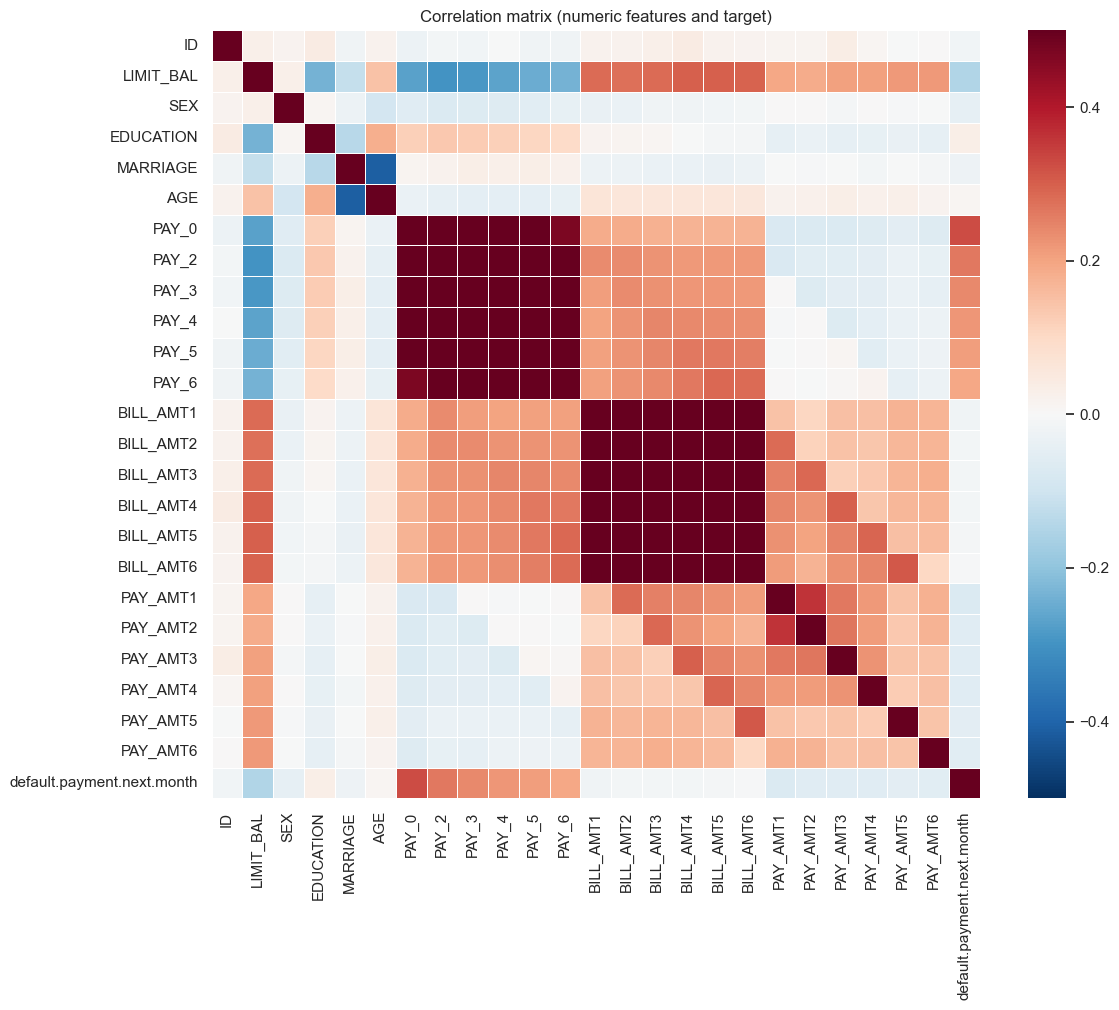

In [72]:
# Correlation with the target
corr_with_target = (
    train_df.corr(numeric_only=True)[target_col]
    .sort_values(ascending=False)
)
print("\nCorrelation of numeric features with the target:")
display(corr_with_target)

# Correlation matrix including target
plt.figure(figsize=(12, 10))
numeric_cols = train_df.select_dtypes(include=[np.number])
sns.heatmap(
    numeric_cols.corr(),
    annot=False,
    cmap="RdBu_r",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    square=True,
    linewidths=0.5,
)
plt.title("Correlation matrix (numeric features and target)")
plt.tight_layout()
plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [73]:
# Apply cleaning to both X_train and X_test
X_train["EDUCATION"] = X_train["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
X_train["MARRIAGE"] = X_train["MARRIAGE"].replace({0: 3})
X_test["EDUCATION"] = X_test["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
X_test["MARRIAGE"] = X_test["MARRIAGE"].replace({0: 3})

In [74]:
# Store original columns for comparison later
original_cols = X_train.columns.tolist()

In [75]:
# Credit Utilization Features

# Average utilization across 6 months
X_train["utilization_avg"] = (
    (X_train["BILL_AMT1"] + X_train["BILL_AMT2"] + X_train["BILL_AMT3"] +
     X_train["BILL_AMT4"] + X_train["BILL_AMT5"] + X_train["BILL_AMT6"]) / 
    (6 * X_train["LIMIT_BAL"])
).replace([np.inf, -np.inf], 0).fillna(0)

X_test["utilization_avg"] = (
    (X_test["BILL_AMT1"] + X_test["BILL_AMT2"] + X_test["BILL_AMT3"] +
     X_test["BILL_AMT4"] + X_test["BILL_AMT5"] + X_test["BILL_AMT6"]) / 
    (6 * X_test["LIMIT_BAL"])
).replace([np.inf, -np.inf], 0).fillna(0)

# Maximum utilization reached
X_train["utilization_max"] = (
    X_train[["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", 
             "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]]
    .div(X_train["LIMIT_BAL"], axis=0)
    .max(axis=1)
).replace([np.inf, -np.inf], 0).fillna(0)

X_test["utilization_max"] = (
    X_test[["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", 
             "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]]
    .div(X_test["LIMIT_BAL"], axis=0)
    .max(axis=1)
).replace([np.inf, -np.inf], 0).fillna(0)

# Utilization trend (recent vs. oldest)
X_train["utilization_trend"] = (
    (X_train["BILL_AMT1"] / X_train["LIMIT_BAL"]) - 
    (X_train["BILL_AMT6"] / X_train["LIMIT_BAL"])
).replace([np.inf, -np.inf], 0).fillna(0)

X_test["utilization_trend"] = (
    (X_test["BILL_AMT1"] / X_test["LIMIT_BAL"]) - 
    (X_test["BILL_AMT6"] / X_test["LIMIT_BAL"])
).replace([np.inf, -np.inf], 0).fillna(0)

In [76]:
# Payment Behavior Features

# Average payment coverage (what % of bill was paid)
X_train["payment_coverage_avg"] = (
    (X_train["PAY_AMT1"] / (X_train["BILL_AMT1"] + 1) +
     X_train["PAY_AMT2"] / (X_train["BILL_AMT2"] + 1) +
     X_train["PAY_AMT3"] / (X_train["BILL_AMT3"] + 1) +
     X_train["PAY_AMT4"] / (X_train["BILL_AMT4"] + 1) +
     X_train["PAY_AMT5"] / (X_train["BILL_AMT5"] + 1) +
     X_train["PAY_AMT6"] / (X_train["BILL_AMT6"] + 1)) / 6
).replace([np.inf, -np.inf], 0).fillna(0)

X_test["payment_coverage_avg"] = (
    (X_test["PAY_AMT1"] / (X_test["BILL_AMT1"] + 1) +
     X_test["PAY_AMT2"] / (X_test["BILL_AMT2"] + 1) +
     X_test["PAY_AMT3"] / (X_test["BILL_AMT3"] + 1) +
     X_test["PAY_AMT4"] / (X_test["BILL_AMT4"] + 1) +
     X_test["PAY_AMT5"] / (X_test["BILL_AMT5"] + 1) +
     X_test["PAY_AMT6"] / (X_test["BILL_AMT6"] + 1)) / 6
).replace([np.inf, -np.inf], 0).fillna(0)

# Total months with any delay
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
X_train["months_delayed"] = (X_train[pay_cols] > 0).sum(axis=1)
X_test["months_delayed"] = (X_test[pay_cols] > 0).sum(axis=1)

# Maximum delay across all months
X_train["max_delay_months"] = X_train[pay_cols].max(axis=1)
X_test["max_delay_months"] = X_test[pay_cols].max(axis=1)

# Clip extreme outliers from payment_coverage_avg
X_train["payment_coverage_avg"] = X_train["payment_coverage_avg"].clip(0, 5.0)
X_test["payment_coverage_avg"] = X_test["payment_coverage_avg"].clip(0, 5.0)

In [77]:
# Financial Trajectory Features

# Bill momentum (rate of change)
X_train["bill_momentum"] = (X_train["BILL_AMT1"] - X_train["BILL_AMT6"]) / 6
X_test["bill_momentum"] = (X_test["BILL_AMT1"] - X_test["BILL_AMT6"]) / 6

# Total outstanding balance (bills - payments)
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", 
             "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_cols_amt = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", 
                "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

X_train["total_outstanding"] = X_train[bill_cols].sum(axis=1) - X_train[pay_cols_amt].sum(axis=1)
X_test["total_outstanding"] = X_test[bill_cols].sum(axis=1) - X_test[pay_cols_amt].sum(axis=1)

In [78]:
# Interaction Features

# Max delay × credit limit interaction
X_train["delay_x_limit"] = X_train["max_delay_months"] * X_train["LIMIT_BAL"]
X_test["delay_x_limit"] = X_test["max_delay_months"] * X_test["LIMIT_BAL"]

# Age × max delay interaction
X_train["age_x_delay"] = X_train["AGE"] * X_train["max_delay_months"]
X_test["age_x_delay"] = X_test["AGE"] * X_test["max_delay_months"]

In [79]:
# Summary
new_features = [c for c in X_train.columns if c not in original_cols]
print(f"Original features: {len(original_cols)}")
print(f"New features added: {len(new_features)}")
print(f"Total features: {X_train.shape[1]}")
print(f"\nNew features: {new_features}")

X_train[new_features].describe()

Original features: 24
New features added: 10
Total features: 34

New features: ['utilization_avg', 'utilization_max', 'utilization_trend', 'payment_coverage_avg', 'months_delayed', 'max_delay_months', 'bill_momentum', 'total_outstanding', 'delay_x_limit', 'age_x_delay']


,utilization_avg,utilization_max,utilization_trend,payment_coverage_avg,months_delayed,max_delay_months,bill_momentum,total_outstanding,delay_x_limit,age_x_delay
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,2.100000e+04,2.100000e+04,21000.000000
mean,0.372906,0.495012,0.106489,1.064875,0.828667,0.436857,2056.727349,2.382835e+05,2.167010e+04,14.918095
std,0.353387,0.436968,0.303408,1.757350,1.549776,1.341855,7251.326806,3.644334e+05,2.508089e+05,49.911212
min,-0.200154,-0.100000,-1.827300,0.000000,0.000000,-2.000000,-71465.166667,-2.671514e+06,-1.560000e+06,-146.000000
25%,0.029820,0.070230,-0.028651,0.039280,0.000000,0.000000,-495.125000,4.719750e+03,0.000000e+00,0.000000
50%,0.281744,0.429709,0.007202,0.077635,0.000000,0.000000,165.583333,1.021710e+05,0.000000e+00,0.000000
75%,0.686824,0.924218,0.184008,1.163683,1.000000,2.000000,3305.666667,3.047652e+05,1.000000e+05,50.000000
max,5.364308,10.688575,5.309500,5.000000,6.000000,8.000000,86433.666667,4.116080e+06,2.800000e+06,480.000000


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

### Feature Type Classification

#### 1. **Numerical Features (Continuous)**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `LIMIT_BAL`, `BILL_AMT1-6`, `PAY_AMT1-6` | StandardScaler | Monetary amounts on different scales |
| `AGE` | StandardScaler | Already reasonable range |
| `utilization_avg`, `utilization_max`, `utilization_trend` | StandardScaler | Ratios, well-behaved |
| `bill_momentum`, `total_outstanding` | RobustScaler | Large range, potential outliers |
| `delay_x_limit`, `age_x_delay` | StandardScaler | Interaction terms, large magnitudes |

#### 2. **Numerical with Outliers (Needs Special Handling)**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `payment_coverage_avg` | Clip at 99th percentile (or 5.0), then StandardScaler | Extreme outliers (max 83,050) from zero-bill divisions |

#### 3. **Ordinal Features**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `EDUCATION` (1=grad, 2=uni, 3=high, 4=other) | OrdinalEncoder | Ordered hierarchy |
| `PAY_0` through `PAY_6` (-2 to 8+) | StandardScaler | Numeric ordinal; scaled for compatibility with linear models |
| `months_delayed`, `max_delay_months` | StandardScaler | Count-based; scaled for compatibility with linear models |

#### 4. **Binary/Categorical Features**
| Feature | Transformation | Rationale |
|---------|----------------|-----------|
| `SEX` (1=male, 2=female) | OneHotEncoder(drop='if_binary', sparse_output=False) | Binary variable |
| `MARRIAGE` (1=married, 2=single, 3=other) | OneHotEncoder | 3 categories, no inherent order |

#### 5. **Identifier (Drop)**
| Feature | Action | Rationale |
|---------|--------|-----------|
| `ID` | Drop | No predictive value |

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [80]:
# Define Feature Groups

# Drop: ID has no predictive value
drop_features = ["ID"]

# StandardScaler: Monetary amounts, well-behaved ratios, and clipped payment coverage
standard_numeric = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "months_delayed", "max_delay_months",
    "utilization_avg", "utilization_max", "utilization_trend",
    "payment_coverage_avg",
    "delay_x_limit", "age_x_delay"
]

# RobustScaler: Features with outliers
robust_numeric = ["bill_momentum", "total_outstanding"]

# OrdinalEncoder: Ordered categorical feature
ordinal_features = ["EDUCATION"]

# OneHotEncoder: Categorical features
categorical_features = ["SEX", "MARRIAGE"]

In [81]:
# Define ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("drop", "drop", drop_features),
        ("standard_scaler", StandardScaler(), standard_numeric),
        ("robust_scaler", RobustScaler(), robust_numeric),
        ("ordinal", OrdinalEncoder(categories=[[1, 2, 3, 4]]), ordinal_features),
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

In [82]:
# Fit and Transform

# Fit on training data, transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

print(f"Features before preprocessing: {X_train.shape[1]}")
print(f"Features after preprocessing: {X_train_processed.shape[1]}")
print(f"\nFeature names: {feature_names}") 

Features before preprocessing: 34
Features after preprocessing: 35

Feature names: ['standard_scaler__LIMIT_BAL' 'standard_scaler__AGE'
 'standard_scaler__BILL_AMT1' 'standard_scaler__BILL_AMT2'
 'standard_scaler__BILL_AMT3' 'standard_scaler__BILL_AMT4'
 'standard_scaler__BILL_AMT5' 'standard_scaler__BILL_AMT6'
 'standard_scaler__PAY_AMT1' 'standard_scaler__PAY_AMT2'
 'standard_scaler__PAY_AMT3' 'standard_scaler__PAY_AMT4'
 'standard_scaler__PAY_AMT5' 'standard_scaler__PAY_AMT6'
 'standard_scaler__PAY_0' 'standard_scaler__PAY_2'
 'standard_scaler__PAY_3' 'standard_scaler__PAY_4'
 'standard_scaler__PAY_5' 'standard_scaler__PAY_6'
 'standard_scaler__months_delayed' 'standard_scaler__max_delay_months'
 'standard_scaler__utilization_avg' 'standard_scaler__utilization_max'
 'standard_scaler__utilization_trend'
 'standard_scaler__payment_coverage_avg' 'standard_scaler__delay_x_limit'
 'standard_scaler__age_x_delay' 'robust_scaler__bill_momentum'
 'robust_scaler__total_outstanding' 'ordinal__

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [83]:
# Create baseline model (always predicts majority class)
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=123)

# Evaluate with cross-validation using F1, ROC-AUC, Recall
dummy_scores = cross_validate(
    dummy_clf, 
    X_train_processed, 
    y_train, 
    cv=5, 
    scoring=["f1", "roc_auc", "recall"],
    return_train_score=True
)

In [84]:
# Display results
print("DummyClassifier (Most Frequent) - Baseline Results:")
print(f"F1-Score:     {dummy_scores['test_f1'].mean():.4f} (+/- {dummy_scores['test_f1'].std():.4f})")
print(f"ROC-AUC:      {dummy_scores['test_roc_auc'].mean():.4f} (+/- {dummy_scores['test_roc_auc'].std():.4f})")
print(f"Recall:       {dummy_scores['test_recall'].mean():.4f} (+/- {dummy_scores['test_recall'].std():.4f})")

DummyClassifier (Most Frequent) - Baseline Results:
F1-Score:     0.0000 (+/- 0.0000)
ROC-AUC:      0.5000 (+/- 0.0000)
Recall:       0.0000 (+/- 0.0000)


In [85]:
# For reference later on
print(f"\nClass distribution in training set:")
print(f"Non-default (0): {(y_train == 0).mean():.3f}")
print(f"Default (1):     {(y_train == 1).mean():.3f}")


Class distribution in training set:
Non-default (0): 0.777
Default (1):     0.223


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

### Summary

Logistic regression with balanced class weights achieves CV F1-score of 0.53 and ROC-AUC of 0.76. Hyperparameter tuning selected C=0.01 (strong regularization), yet train and CV scores are nearly identical, indicating the model is underfitting. The linear decision boundary is insufficient for this dataset. A non-linear model is likely needed.

In [86]:
scoring = ["f1", "roc_auc", "recall"]

# Quick cross-validation with default C to understand baseline linear performance
lr_default = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=123)
)

default_scores = cross_validate(
    lr_default, X_train_processed, y_train,
    cv=5, scoring=scoring, return_train_score=True
)

print("LogisticRegression (default C=1.0):")
for metric in scoring:
    print(f"  {metric:8s}: {default_scores[f'test_{metric}'].mean():.4f} (+/- {default_scores[f'test_{metric}'].std():.4f})")

LogisticRegression (default C=1.0):
  f1      : 0.5290 (+/- 0.0082)
  roc_auc : 0.7588 (+/- 0.0075)
  recall  : 0.6237 (+/- 0.0067)


In [87]:
# Hyperparameter tuning over C
param_dist = {"logisticregression__C": loguniform(1e-4, 1e3)}

lr_pipe = make_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=123)
)

random_search = RandomizedSearchCV(
    lr_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    refit=True,
    random_state=123,
    n_jobs=-1,
    return_train_score=True,
)

random_search.fit(X_train_processed, y_train)

print(f"Best C:       {random_search.best_params_['logisticregression__C']:.5f}")
print(f"Best CV F1:   {random_search.best_score_:.4f}")

Best C:       0.01007
Best CV F1:   0.5301


In [88]:
# Evaluate best model across all metrics
best_lr = random_search.best_estimator_

tuned_scores = cross_validate(
    best_lr, X_train_processed, y_train,
    cv=5, scoring=scoring, return_train_score=True
)

print("LogisticRegression (tuned):")
for metric in scoring:
    train = tuned_scores[f'train_{metric}'].mean()
    test  = tuned_scores[f'test_{metric}'].mean()
    std   = tuned_scores[f'test_{metric}'].std()
    print(f"  {metric:8s}  train={train:.4f}  CV={test:.4f} (+/- {std:.4f})")

LogisticRegression (tuned):
  f1        train=0.5299  CV=0.5301 (+/- 0.0096)
  roc_auc   train=0.7609  CV=0.7576 (+/- 0.0082)
  recall    train=0.6239  CV=0.6250 (+/- 0.0083)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [89]:
...

Ellipsis

In [90]:
...

Ellipsis

In [91]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [92]:
...

Ellipsis

In [93]:
...

Ellipsis

In [94]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [95]:
...

Ellipsis

In [96]:
...

Ellipsis

In [97]:
...

Ellipsis

In [98]:
...

Ellipsis

In [99]:
...

Ellipsis

In [100]:
...

Ellipsis

In [101]:
...

Ellipsis

In [102]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [103]:
...

Ellipsis

In [104]:
...

Ellipsis

In [105]:
...

Ellipsis

In [106]:
...

Ellipsis

In [107]:
...

Ellipsis

In [108]:
...

Ellipsis

In [109]:
...

Ellipsis

In [110]:
...

Ellipsis

In [111]:
...

Ellipsis

In [112]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [113]:
...

Ellipsis

In [114]:
...

Ellipsis

In [115]:
...

Ellipsis

In [116]:
...

Ellipsis

In [117]:
...

Ellipsis

In [118]:
...

Ellipsis

In [119]:
...

Ellipsis

In [120]:
...

Ellipsis

In [121]:
...

Ellipsis

In [122]:
...

Ellipsis

In [123]:
...

Ellipsis

In [124]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [125]:
...

Ellipsis

In [126]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)